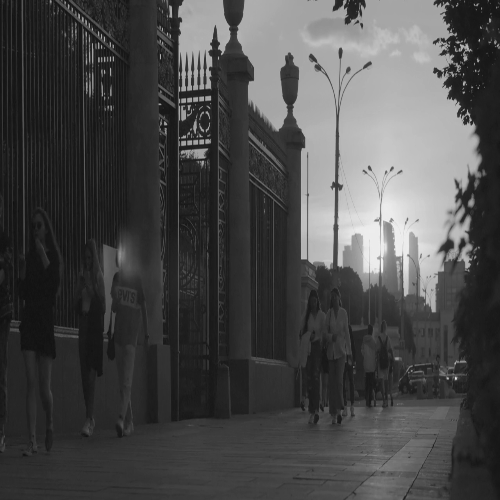

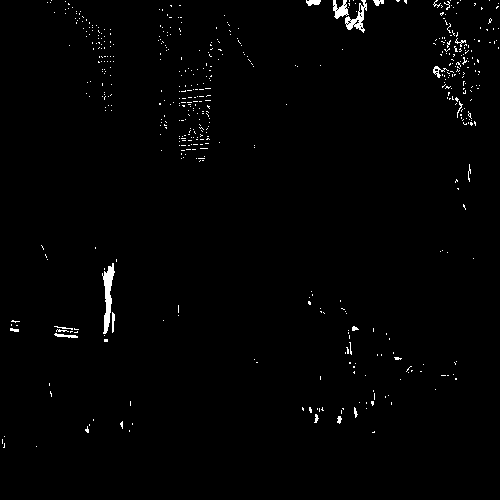

In [ ]:
import cv2
import numpy as np
from IPython.display import display, clear_output
from PIL import Image

# Load the video
cap = cv2.VideoCapture("/content/Video1.mp4")
background = None

while cap.isOpened():
    r, f = cap.read()
    if not r:
        break

    # Convert frame to grayscale
    g = cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)

    # Resize frame for better processing
    gf = cv2.resize(g, (500, 500))

    # Initialize background
    if background is None:
        background = gf.astype("float")
        continue

    # Update background model
    cv2.accumulateWeighted(gf, background, 0.01)  # learning rate

    # Compute absolute difference
    diff_frame = cv2.absdiff(gf, cv2.convertScaleAbs(background))

    # Apply threshold to get foreground mask
    _, fg_mask = cv2.threshold(diff_frame, 25, 255, cv2.THRESH_BINARY)

    # Convert frames to displayable format
    original_img = Image.fromarray(gf)
    mask_img = Image.fromarray(fg_mask)

    # Clear output and display images in Jupyter Notebook
    clear_output(wait=True)
    display(original_img, mask_img)

cap.release()